In [20]:
import tkinter as tk
from tkinter import filedialog, messagebox
import pandas as pd
from IPython.display import display, HTML

# open file picker
root = tk.Tk()
root.withdraw()
file_path = filedialog.askopenfilename(title="Select CSV file", filetypes=[("CSV files", "*.csv")])

# load whatever csv they picked
df = pd.read_csv(file_path)
print(f"Loaded: {file_path}")
print(df.shape)
print(df[' Label'].value_counts())

# popup indicator
if df[' Label'].nunique() == 1:
    display(HTML("""
        <div style="background-color:#00cc66; color:white; padding:15px; 
        border-radius:8px; font-size:16px; font-weight:bold;">
        ✅ No Attacks Detected — This file only contains BENIGN traffic. 
        Please load a file with attack traffic.
        </div>
    """))
else:
    attack_types = [l for l in df[' Label'].unique() if l != 'BENIGN']
    display(HTML(f"""
        <div style="background-color:#ff4444; color:white; padding:15px; 
        border-radius:8px; font-size:16px; font-weight:bold;">
        ⚠️ Attack types detected: {", ".join(attack_types)}
        </div>
    """))

Loaded: /Users/niakumar/Downloads/network-intrusion-detection/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
(225745, 79)
 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


In [21]:
import numpy as np

# drop nulls and infinities
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# encode label as binary
df['label_binary'] = (df[' Label'] == 'DDoS').astype(int)

# features and target
X = df.drop(columns=[' Label', 'label_binary'])
y = df['label_binary']

print(X.shape)
print(y.value_counts())

(225711, 78)
label_binary
1    128025
0     97686
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from IPython.display import display, HTML

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train the model
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# evaluate
y_pred = clf.predict(X_test)

report = classification_report(y_test, y_pred, output_dict=True)

rows = ""
for label, metrics in report.items():
    if label in ['0', '1']:
        name = "🟢 BENIGN" if label == '0' else "🔴 ATTACK"
        rows += f"""
        <tr>
            <td><b>{name}</b></td>
            <td>{metrics['precision']:.2%}</td>
            <td>{metrics['recall']:.2%}</td>
            <td>{metrics['f1-score']:.2%}</td>
            <td>{int(metrics['support'])}</td>
        </tr>
        """

accuracy = report['accuracy']

display(HTML(f"""
<h3 style="font-family:Arial">📊 Model Performance Report</h3>
<table style="font-family:Arial; border-collapse:collapse; width:60%">
    <thead>
        <tr style="background-color:#333; color:white; text-align:center;">
            <th style="padding:10px">Traffic Type</th>
            <th style="padding:10px">Precision</th>
            <th style="padding:10px">Recall</th>
            <th style="padding:10px">F1 Score</th>
            <th style="padding:10px">Samples</th>
        </tr>
    </thead>
    <tbody style="text-align:center">
        {rows}
        <tr style="background-color:#333; color:white; font-weight:bold;">
            <td style="padding:10px">Overall Accuracy</td>
            <td colspan="4" style="padding:10px">{accuracy:.2%}</td>
        </tr>
    </tbody>
</table>
<br>
<p style="font-family:Arial; font-size:13px; color:white">
<b>Precision:</b> Of all traffic flagged as attacks, how many were actually attacks.<br>
<b>Recall:</b> Of all actual attacks, how many did the model catch.<br>
<b>F1 Score:</b> Balance between precision and recall.<br>
<b>Samples:</b> Number of connections tested.
</p>
"""))

In [35]:
import umap
import plotly.express as px
import pandas as pd

# sample 5000 rows
sample = df.sample(5000, random_state=42)
X_sample = sample.drop(columns=[' Label', 'label_binary'])
y_sample = sample['label_binary']

# fit UMAP in 3D
reducer = umap.UMAP(n_components=3, random_state=42)
embedding = reducer.fit_transform(X_sample)

# create dataframe for plotly
embed_df = pd.DataFrame(embedding, columns=['UMAP 1', 'UMAP 2', 'UMAP 3'])
embed_df['Traffic Type'] = y_sample.values
embed_df['Traffic Type'] = embed_df['Traffic Type'].map({0: 'BENIGN', 1: 'DDoS Attack'})

# interactive plot
fig = px.scatter_3d(embed_df, x='UMAP 1', y='UMAP 2', z='UMAP 3',
                    color='Traffic Type',
                    color_discrete_map={'BENIGN': 'blue', 'DDoS Attack': 'red'},
                    title='3D UMAP Projection of Network Traffic',
                    opacity=0.5)

fig.update_traces(marker=dict(size=2))
fig.update_layout(
    title=dict(text='3D UMAP Projection of Network Traffic', font=dict(family="Courier New, monospace", size=18, weight='bold')),
    font=dict(family="Courier New, monospace", size=13),
    legend=dict(
        itemsizing='constant',
        itemwidth=30,
        bgcolor='white',
        bordercolor='#cccccc',
        borderwidth=2,
        xanchor='right',
        x=1
    ),
    paper_bgcolor='#e8f5e9',
    scene=dict(bgcolor='#e8f5e9')
)
fig.show()

/Users/niakumar/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


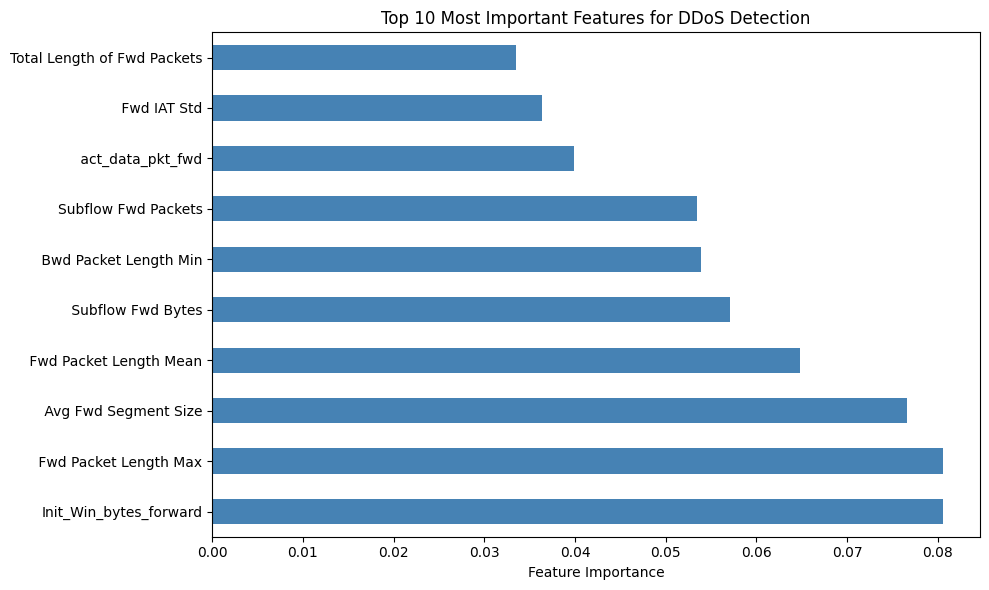

Feature,Importance Score,What it means
Init_Win_bytes_forward,0.0806,Byte transfer rate — unusually high rates indicate flooding behavior
Fwd Packet Length Max,0.0805,Packet length statistic — DDoS floods often have unusual packet sizing
Avg Fwd Segment Size,0.0766,Network traffic feature used by the model to distinguish attack patterns
Fwd Packet Length Mean,0.0648,Packet length statistic — DDoS floods often have unusual packet sizing
Subflow Fwd Bytes,0.0571,Byte transfer rate — unusually high rates indicate flooding behavior
Bwd Packet Length Min,0.0539,Packet length statistic — DDoS floods often have unusual packet sizing
Subflow Fwd Packets,0.0535,Packet length statistic — DDoS floods often have unusual packet sizing
act_data_pkt_fwd,0.0399,Network traffic feature used by the model to distinguish attack patterns
Fwd IAT Std,0.0364,Network traffic feature used by the model to distinguish attack patterns
Total Length of Fwd Packets,0.0335,Packet length statistic — DDoS floods often have unusual packet sizing


In [36]:
import pandas as pd
from IPython.display import display, HTML

feature_importance = pd.Series(clf.feature_importances_, index=X.columns)
top_features = feature_importance.nlargest(10)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Important Features for DDoS Detection')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

rows = ""
for feature, score in top_features.items():
    rows += f"""
    <tr>
        <td style="padding:8px"><b>{feature.strip()}</b></td>
        <td style="padding:8px">{score:.4f}</td>
        <td style="padding:8px; color:#aaa; font-size:12px">{
            "Initial TCP window size — abnormal values are a strong DDoS indicator" if "init_win" in feature else
            "Packet length statistic — DDoS floods often have unusual packet sizing" if "Packet" in feature or "packet" in feature else
            "Flow duration — DDoS attacks often have very short or very long flows" if "Duration" in feature or "duration" in feature else
            "Byte transfer rate — unusually high rates indicate flooding behavior" if "Byte" in feature or "byte" in feature else
            "Flag count — abnormal TCP flag patterns are common in attacks" if "Flag" in feature or "flag" in feature else
            "Flow volume metric — high volumes in short time windows signal attacks" if "Flow" in feature or "flow" in feature else
            "Network traffic feature used by the model to distinguish attack patterns"
        }</td>
    </tr>
    """

display(HTML(f"""
<h3 style="font-family:Arial">🔍 Feature Importance Breakdown</h3>
<table style="font-family:Arial; border-collapse:collapse; width:80%">
    <thead>
        <tr style="background-color:#333; color:white; text-align:left;">
            <th style="padding:10px">Feature</th>
            <th style="padding:10px">Importance Score</th>
            <th style="padding:10px">What it means</th>
        </tr>
    </thead>
    <tbody>
        {rows}
    </tbody>
</table>
<br>
<p style="font-family:Arial; font-size:13px; color:white">
Higher importance score = the model relied on this feature more heavily to detect attacks.
</p>
"""))